## 1. Încărcarea și explorarea ințială

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('bank.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [2]:
df.shape


(11162, 17)

df.columns

In [3]:
df.dtypes


age          int64
job            str
marital        str
education      str
default        str
balance      int64
housing        str
loan           str
contact        str
day          int64
month          str
duration     int64
campaign     int64
pdays        int64
previous     int64
poutcome       str
deposit        str
dtype: object

## 2. Data cleaning

In [4]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [5]:
for col in ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome', 'deposit']:
    print(f"\n{col}:")
    print(df[col].value_counts())


job:
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

marital:
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64

education:
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64

default:
default
no     10994
yes      168
Name: count, dtype: int64

housing:
housing
no     5881
yes    5281
Name: count, dtype: int64

loan:
loan
no     9702
yes    1460
Name: count, dtype: int64

contact:
contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64

poutcome:
poutcome
unknown    8326
failure    1228
success    1071
other       537
Name: count, dtype: int64

deposit:
deposit
no     5873
yes    5289
Name: count, dtype: int64


## Concluzii Data Cleaning

Datasetul nu conține valori lipsă. Valorile 'unknown' din 
coloanele poutcome și contact reprezintă categorii valide 
(clienți fără istoric anterior), nu erori de date.

In [6]:
df['deposit'].value_counts(normalize=True) * 100

deposit
no     52.616019
yes    47.383981
Name: proportion, dtype: float64

In [7]:
print(df['poutcome'].value_counts())
print()
print(df.groupby('poutcome')['deposit'].value_counts(normalize=True) * 100)

poutcome
unknown    8326
failure    1228
success    1071
other       537
Name: count, dtype: int64

poutcome  deposit
failure   yes        50.325733
          no         49.674267
other     yes        57.169460
          no         42.830540
success   yes        91.316527
          no          8.683473
unknown   no         59.332212
          yes        40.667788
Name: proportion, dtype: float64


In [8]:
known = df[df['poutcome'] != 'unknown']
print(known.groupby('poutcome')['deposit'].value_counts(normalize=True) * 100)

poutcome  deposit
failure   yes        50.325733
          no         49.674267
other     yes        57.169460
          no         42.830540
success   yes        91.316527
          no          8.683473
Name: proportion, dtype: float64


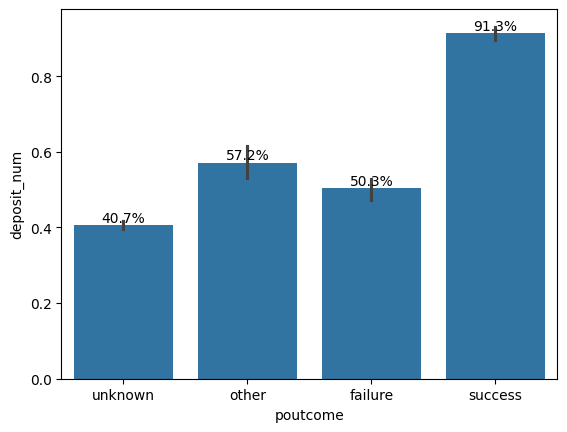

In [32]:
df['deposit_num'] = (df['deposit'] == 'yes').astype(int)
ax = sns.barplot(data=df, x='poutcome', y='deposit_num')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.show()

In [17]:
df.groupby('job')['deposit_num'].mean().sort_values(ascending=False) * 100

job
student          74.722222
retired          66.323907
unemployed       56.582633
management       50.701481
unknown          48.571429
admin.           47.301349
self-employed    46.172840
technician       46.077894
services         39.978332
housemaid        39.781022
entrepreneur     37.500000
blue-collar      36.419753
Name: deposit_num, dtype: float64

In [21]:
df.groupby('job').agg(
    numar_clienti=('deposit_num', 'count'),
    rata_conversie=('deposit_num', 'mean')
).sort_values('numar_clienti', ascending=False) 

,numar_clienti,rata_conversie
job,,
management,2566,0.507015
blue-collar,1944,0.364198
technician,1823,0.460779
admin.,1334,0.473013
services,923,0.399783
retired,778,0.663239
self-employed,405,0.461728
student,360,0.747222
unemployed,357,0.565826


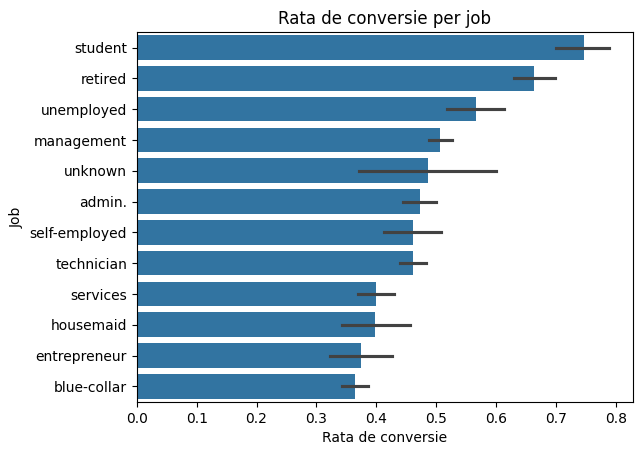

In [40]:
order = df.groupby('job')['deposit_num'].mean().sort_values(ascending=False).index

sns.barplot(data=df, y='job', x='deposit_num', order=order)
plt.title('Rata de conversie per job')
plt.xlabel('Rata de conversie')
plt.ylabel('Job')
plt.show()

## În urma analizei ratei de conversie per joburile clientilor identificăm următoarele:
1. Cele mai mare aporturi le au: 
    I loc - managmenet cu o rata de conversie de 50.7% pentru 2566 pers.
   II loc - tehnician cu rata de conversie 46.07% pentru 1823 pers.
   III loc- admin cu rata 47.3% pentru 1334 pers.
3. Conversia de 36.42% pentru 1994 pers semnificativa dar ne explorată pe deplin o au cei din sectorul blue collar cu potenția de creștere.
4. Segmentul care merită să fie explorat pentru retentie sunt ”retired” la un aport mediu dar conversia ridicată.

## 3. Analizam influența factorului ”campaign” - număr de contacte asupra conversiei.

In [41]:
print(df.groupby('campaign')['deposit'].value_counts(normalize=True) * 100)

campaign  deposit
1         yes         53.376407
          no          46.623593
2         no          53.731836
          yes         46.268164
3         no          53.217260
          yes         46.782740
4         no          58.884565
          yes         41.115435
5         no          63.227513
          yes         36.772487
6         no          65.283019
          yes         34.716981
7         no          66.187050
          yes         33.812950
8         no          75.000000
          yes         25.000000
9         no          70.833333
          yes         29.166667
10        no          73.076923
          yes         26.923077
11        no          60.000000
          yes         40.000000
12        no          86.206897
          yes         13.793103
13        no          80.000000
          yes         20.000000
14        no          73.333333
          yes         26.666667
15        no          69.230769
          yes         30.769231
16        no          

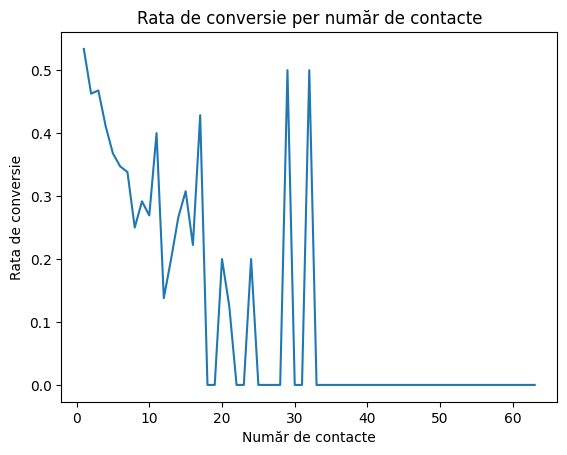

In [42]:
df.groupby('campaign')['deposit_num'].mean().plot()
plt.title('Rata de conversie per număr de contacte')
plt.xlabel('Număr de contacte')
plt.ylabel('Rata de conversie')
plt.show()

In [48]:
df['campaign'].value_counts().sort_index().head(20)

campaign
1     4798
2     3028
3     1321
4      771
5      378
6      265
7      139
8      128
9       72
10      52
11      40
12      29
13      30
14      15
15      13
16       9
17      14
18       8
19       5
20       5
Name: count, dtype: int64

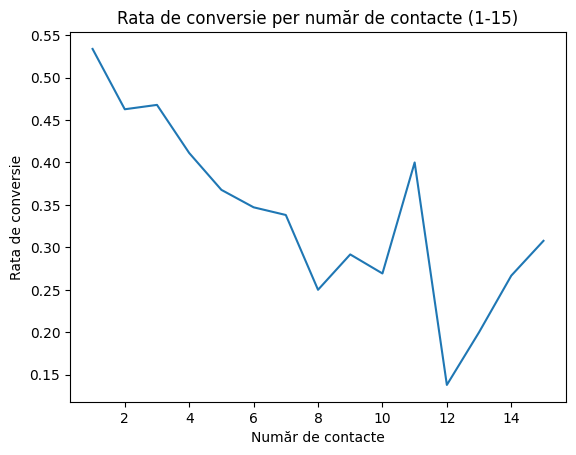

In [49]:
df[df['campaign'] <= 15].groupby('campaign')['deposit_num'].mean().plot()
plt.title('Rata de conversie per număr de contacte (1-15)')
plt.xlabel('Număr de contacte')
plt.ylabel('Rata de conversie')
plt.show()

In [51]:
tabel = df.groupby('campaign').agg(
    total_clienti=('deposit_num', 'count'),
    conversii=('deposit_num', 'sum')
)
tabel['cota_parte'] = tabel['conversii'] / tabel['conversii'].sum() * 100
tabel.loc[tabel.index <= 15]

,total_clienti,conversii,cota_parte
campaign,,,
1,4798,2561,48.421252
2,3028,1401,26.488939
3,1321,618,11.684628
4,771,317,5.993572
5,378,139,2.628096
6,265,92,1.739459
7,139,47,0.888637
8,128,32,0.605029
9,72,21,0.397050


## Concluziile analizei factorului ”campaign”
În urma analizei identificam următoroarele:
1. Primile 3 contacte sunt cele mai eficiente sunt primile 3 care in suma convertesc 86,6 % din totalul conversiilor
2. Începând cu a 11-lea contact conversiile scad dramatic și mai departe sporesc cheltuielile fara rezultate semnificative.

## 4. Analiza factorului varsta

In [53]:
df['age_group'] = pd.cut(df['age'], 
                          bins=[0, 25, 35, 50, 65, 100],
                          labels=['<25', '25-35', '35-50', '50-65', '65+'])

df.groupby('age_group')['deposit_num'].mean().sort_values(ascending=False)

age_group
65+      0.804020
<25      0.711111
50-65    0.479016
25-35    0.476664
35-50    0.413657
Name: deposit_num, dtype: float64

Concluzii : depozitul la termen e mai atractiv pentru cei care deja au capital (65+) sau nu au cheltuieli mari încă (<25).

## 5. Analiza influentei factorului ”balance” - soldul bancar la momentul campaniei

In [57]:
print(df['balance'].min())
print(df['balance'].max())
df['balance'].describe()

-6847
81204


count    11162.000000
mean      1528.538524
std       3225.413326
min      -6847.000000
25%        122.000000
50%        550.000000
75%       1708.000000
max      81204.000000
Name: balance, dtype: float64

In [59]:
df['balance_group'] = pd.qcut(df['balance'], 
                               q=4,
                               labels=['Q1 <122', 'Q2 122-550', 'Q3 550-1708', 'Q4 >1708'])
df.groupby('balance_group')['deposit_num'].mean().sort_values(ascending=False)

balance_group
Q4 >1708       0.574910
Q3 550-1708    0.498745
Q2 122-550     0.462200
Q1 <122        0.359599
Name: deposit_num, dtype: float64

Concluzie :
Soldul bancar e un predictor direct al conversiei — clienții cu sold peste 1708€ convertesc cu 60% mai frecvent decât cei cu sold sub 122€.

## Concluzii finale
* În urma analizei explorative a campaniei de marketing bancar, profilul clientului cu cea mai mare probabilitate de conversie la depozit la termen este următorul:
* Demografic: Clienți cu vârsta sub 25 de ani sau peste 65 de ani, cu ocupații în management, tehnic și administrativ. Pensionarii reprezintă un segment cu rată de conversie ridicată (66%) la un volum mediu, justificând o strategie de retenție dedicată.
* Potențial neexplorat: Sectorul blue-collar, cu cel mai mare volum de clienți (1944) și o rată de conversie de 36%, reprezintă o oportunitate semnificativă de creștere prin campanii țintite.
* Financiar: Clienții cu sold bancar peste 1708€ convertesc în proporție de 57%, față de 36% pentru cei cu sold sub 122€.
* Eficiența campaniei: Primele 3 contacte generează 86.6% din totalul conversiilor. Contactele după al 11-lea au utilitate marginală minimă și cresc nejustificat costurile campaniei.
* Factor critic: Clienții cu campanie anterioară de succes convertesc în proporție de 91% — recontactarea acestui segment trebuie să fie prioritatea numărul 1 a oricărei campanii viitoare.